# 모델 비교 (Model Comparison)

베이스라인(로지스틱 회귀)에서 확장하여 다양한 단일 모델 + 앙상블 모델을 비교합니다.

**포함 모델:**
| 카테고리 | 모델 |
|---|---|
| 선형 | LogisticRegression |
| 트리 단일 | DecisionTree |
| 배깅 | RandomForest |
| 부스팅 | GradientBoosting, XGBoost, LightGBM, CatBoost |
| 스태킹 | StackingClassifier (RF + XGB + LGB → LR) |
| 보팅 | VotingClassifier (hard & soft) |

**흐름:**
1. 경로 설정 및 라이브러리 로드
2. 데이터 로드 및 test 파생변수 생성
3. train / valid 분리 및 전처리기 구성
4. 모델 딕셔너리 정의
5. 전체 모델 학습 및 성능 비교
6. 최적의 모델 시각화 (Confusion Matrix / ROC / PR 커브)
7. test 예측 및 모델 저장
8. 최적의 모델 하이퍼 파라미터 튜닝 및 저장
9. test 예측 및 모델 저장

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
import joblib
import optuna
import time

from pathlib import Path
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.base import clone
from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier,
    StackingClassifier,
    VotingClassifier,
    BaggingClassifier,
    ExtraTreesClassifier,
)
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    RocCurveDisplay,
    PrecisionRecallDisplay,
    average_precision_score,
    fbeta_score
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from optuna.samplers import TPESampler

optuna.logging.set_verbosity(optuna.logging.WARNING)  # 불필요한 로그 억제

# XGBoost / LightGBM / CatBoost (설치된 경우에만)
try:
    from xgboost import XGBClassifier
    HAS_XGB = True
except ImportError:
    HAS_XGB = False
    print("[경고] xgboost 미설치. pip install xgboost")

try:
    from lightgbm import LGBMClassifier
    HAS_LGB = True
except ImportError:
    HAS_LGB = False
    print("[경고] lightgbm 미설치. pip install lightgbm")

try:
    from catboost import CatBoostClassifier
    HAS_CAT = True
except ImportError:
    HAS_CAT = False
    print("[경고] catboost 미설치. pip install catboost")

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 200)

# 한글 폰트 설정(Windows)
plt.rcParams['font.family'] = 'Malgun Gothic'  # 맑은 고딕
plt.rcParams['axes.unicode_minus'] = False     # 마이너스 깨짐 방지

# 한글 폰트 설정(Mac)
# plt.rcParams['font.family'] = 'AppleGothic'
# plt.rcParams['axes.unicode_minus'] = False

# 한글 폰트 설정(Linux)
# plt.rcParams['font.family'] = 'NanumGothic'
# plt.rcParams['axes.unicode_minus'] = False

RANDOM_STATE = 42

# ── 경로 설정 (본인 환경에 맞게 수정) ──────────────────────────
DATA_DIR   = Path("../data")
TRAIN_PATH = DATA_DIR / "cc_fraud_train_processed.csv"
TEST_PATH  = DATA_DIR / "cc_fraud_test_processed.csv"

OUTPUT_DIR = Path("../output")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

MODEL_DIR = Path("../model")
MODEL_DIR.mkdir(parents=True, exist_ok=True)


In [2]:
# ── 데이터 로드 ───────────────────────────────────────────────
# train 불필요한 Unnamed 컬럼 제거
train = pd.read_csv(TRAIN_PATH)
train = train.loc[:, ~train.columns.str.contains(r"^Unnamed")]

# test 불필요한 Unnamed 컬럼 제거
test = pd.read_csv(TEST_PATH)
test = test.loc[:, ~test.columns.str.contains(r"^Unnamed")]

# 데이터 크기 확인
print("데이터 크기")
print(f"train shape : {train.shape}")
print(f"test  shape : {test.shape}")

# 데이터 확인
print("\n데이터 샘플")
display(train.head())
display(test.head())

print("\n타겟 분포")
display(train["is_fraud"].value_counts(normalize=True).rename("ratio").to_frame())
display(test["is_fraud"].value_counts(normalize=True).rename("ratio").to_frame())


데이터 크기
train shape : (1296675, 22)
test  shape : (555719, 22)

데이터 샘플


,merchant,category,amt,gender,state,zip,lat,long,city_pop,unix_time,merch_lat,merch_long,is_fraud,trans_hour,trans_dayofweek,trans_month,trans_day,age,distance_km,amt_zscore,hour_dev,high_amt_far
0,"fraud_Rippin, Kub and Mann",misc_net,4.97,F,NC,28654,36.0788,-81.1781,3495,1325376018,36.011293,-82.048315,0,0,1,1,1,31,78.597568,-0.651072,14.021203,0
1,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,F,WA,99160,48.8878,-118.2105,149,1325376044,49.159047,-118.186462,0,0,1,1,1,41,30.212176,0.450243,14.021452,0
2,fraud_Lind-Buckridge,entertainment,220.11,M,ID,83252,42.1808,-112.2620,4154,1325376051,43.150704,-112.154481,0,0,1,1,1,57,108.206083,1.518323,10.339960,0
3,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.00,M,MT,59632,46.2306,-112.1138,1939,1325376076,47.034331,-112.561071,0,0,1,1,1,52,95.673231,-0.186931,12.265720,0
4,fraud_Keeling-Crist,misc_pos,41.96,M,VA,24433,38.4207,-79.4629,99,1325376186,38.674999,-78.632459,0,0,1,1,1,33,77.556744,-0.597057,12.110560,0


,merchant,category,amt,gender,state,zip,lat,long,city_pop,unix_time,merch_lat,merch_long,is_fraud,trans_hour,trans_dayofweek,trans_month,trans_day,age,distance_km,amt_zscore,hour_dev,high_amt_far
0,fraud_Kirlin and Sons,personal_care,2.86,M,SC,29209,33.9659,-80.9355,333497,1371816865,33.986391,-81.200714,0,12,6,6,21,52,24.561462,-0.372001,1.014062,0
1,fraud_Sporer-Keebler,personal_care,29.84,F,UT,84002,40.3207,-110.4360,302,1371816873,39.450498,-109.960431,0,12,6,6,21,30,104.925092,-0.232006,1.823178,0
2,"fraud_Swaniawski, Nitzsche and Welch",health_fitness,41.28,F,NY,11710,40.6729,-73.5365,34496,1371816893,40.495810,-74.196111,0,12,6,6,21,50,59.080078,-0.402674,2.029823,0
3,fraud_Haley Group,misc_pos,60.05,M,FL,32780,28.5697,-80.8191,54767,1371816915,28.812398,-80.883061,0,12,6,6,21,33,27.698567,0.007763,1.680241,0
4,fraud_Johnston-Casper,travel,3.19,M,MI,49632,44.2529,-85.0170,1126,1371816917,44.959148,-85.884734,0,12,6,6,21,65,104.335106,-0.683890,0.319865,0



타겟 분포


,ratio
is_fraud,
0,0.994211
1,0.005789


,ratio
is_fraud,
0,0.99614
1,0.00386


In [3]:
# ── train / valid 분리 ────────────────────────────────────────
X = train.drop(columns=["is_fraud"])
y = train["is_fraud"].astype(int)

X_test = test.drop(columns=["is_fraud"])
y_test = test["is_fraud"].astype(int)

X_train, X_valid, y_train, y_valid = train_test_split(
    X, y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y,
)

print(f"X_train : {X_train.shape}  |  X_valid : {X_valid.shape}  |  X_test : {X_test.shape}")
print('\n')
print(f"사기 비율 (train)  : {y_train.mean():.4f}")
print(f"사기 비율 (valid)  : {y_valid.mean():.4f}")
print(f"사기 비율 (test)   : {y_test.mean():.4f}")


X_train : (1037340, 21)  |  X_valid : (259335, 21)  |  X_test : (555719, 21)


사기 비율 (train)  : 0.0058
사기 비율 (valid)  : 0.0058
사기 비율 (test)   : 0.0039


In [4]:
# ── 공통 전처리기 구성 ────────────────────────────────────────
numeric_features     = X_train.select_dtypes(include=["number"]).columns.tolist()
categorical_features = X_train.select_dtypes(exclude=["number"]).columns.tolist()

print(f"수치형 피처 ({len(numeric_features)}개) : {numeric_features}")
print(f"범주형 피처 ({len(categorical_features)}개) : {categorical_features}")

# 수치형: 결측치(중앙값) → 표준화
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler",  StandardScaler()),
])

# 범주형: 결측치(최빈값) → 원핫인코딩
categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot",  OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
])

preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_transformer,     numeric_features),
    ("cat", categorical_transformer, categorical_features),
], verbose_feature_names_out=False)

print("전처리기 구성 완료")


수치형 피처 (17개) : ['amt', 'zip', 'lat', 'long', 'city_pop', 'unix_time', 'merch_lat', 'merch_long', 'trans_hour', 'trans_dayofweek', 'trans_month', 'trans_day', 'age', 'distance_km', 'amt_zscore', 'hour_dev', 'high_amt_far']
범주형 피처 (4개) : ['merchant', 'category', 'gender', 'state']
전처리기 구성 완료


In [5]:
# ── 모델 딕셔너리 정의 ────────────────────────────────────────
# 불균형 보정: class_weight="balanced" / scale_pos_weight (XGB) / is_unbalance (LGB)
scale_pos = int((y_train == 0).sum() / (y_train == 1).sum())  # ~172

base_models = {
    # ── 선형 ───────────────────────────────────────────────────
    "LogisticRegression": LogisticRegression(
        max_iter=1000, class_weight="balanced",
        solver="liblinear", random_state=RANDOM_STATE,
    ),

    # ── 트리 단일 ──────────────────────────────────────────────
    "DecisionTree": DecisionTreeClassifier(
        max_depth=10, class_weight="balanced",
        random_state=RANDOM_STATE,
    ),

    # ── 배깅 ───────────────────────────────────────────────────
    "RandomForest": RandomForestClassifier(
        n_estimators=300, max_depth=15, class_weight="balanced",
        n_jobs=-1, random_state=RANDOM_STATE,
    ),
    "ExtraTrees": ExtraTreesClassifier(
        n_estimators=300, max_depth=15, class_weight="balanced",
        n_jobs=-1, random_state=RANDOM_STATE,
    ),

    # ── 부스팅 (sklearn) ───────────────────────────────────────
    "GradientBoosting": GradientBoostingClassifier(
        n_estimators=200, max_depth=5, learning_rate=0.05,
        subsample=0.8, random_state=RANDOM_STATE,
    ),
}

# XGBoost
if HAS_XGB:
    base_models["XGBoost"] = XGBClassifier(
        n_estimators=300, max_depth=6, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8,
        scale_pos_weight=scale_pos,
        eval_metric="aucpr",
        use_label_encoder=False,
        n_jobs=-1, random_state=RANDOM_STATE,
    )

# LightGBM
if HAS_LGB:
    base_models["LightGBM"] = LGBMClassifier(
        n_estimators=300, max_depth=6, learning_rate=0.05,
        num_leaves=63, subsample=0.8, colsample_bytree=0.8,
        is_unbalance=True,
        n_jobs=-1, random_state=RANDOM_STATE, verbose=-1,
    )

# CatBoost
if HAS_CAT:
    base_models["CatBoost"] = CatBoostClassifier(
        iterations=300, depth=6, learning_rate=0.05,
        auto_class_weights="Balanced",
        eval_metric="AUC",
        verbose=0, random_state=RANDOM_STATE,
    )

print(f"정의된 base 모델 수: {len(base_models)}")
for name in base_models:
    print(f"  - {name}")


정의된 base 모델 수: 8
  - LogisticRegression
  - DecisionTree
  - RandomForest
  - ExtraTrees
  - GradientBoosting
  - XGBoost
  - LightGBM
  - CatBoost


In [6]:
# ── 앙상블 모델 (Stacking / Voting) 정의 ─────────────────────
# base_models 의 원본 estimator 를 clone 해서 사용
# → Pipeline 없이 순수 모델만 앙상블 내부에 넣어야 함
# → 학습은 아래 CELL 8 에서 preprocessor 포함 Pipeline 으로 감쌈
from sklearn.base import clone

stack_estimators = []
if "RandomForest" in base_models:
    stack_estimators.append(("rf",  clone(base_models["RandomForest"])))
if "XGBoost" in base_models:
    stack_estimators.append(("xgb", clone(base_models["XGBoost"])))
if "LightGBM" in base_models:
    stack_estimators.append(("lgb", clone(base_models["LightGBM"])))
if not stack_estimators:
    stack_estimators = [("rf", clone(base_models["RandomForest"]))]

# 앙상블 모델 정의 (내부 estimator 는 clone 된 순수 모델)
ensemble_models = {
    "Stacking": StackingClassifier(
        estimators=stack_estimators,
        final_estimator=LogisticRegression(
            class_weight="balanced", max_iter=1000, solver="lbfgs",
        ),
        cv=5,
        stack_method="predict_proba",
        n_jobs=1,
        passthrough=False,
    ),
    "SoftVoting": VotingClassifier(
        estimators=stack_estimators,
        voting="soft",
        n_jobs=-1,
    ),
    "HardVoting": VotingClassifier(
        estimators=stack_estimators,
        voting="hard",
        n_jobs=-1,
    ),
}

print(f"앙상블 모델 수: {len(ensemble_models)}")
for name in ensemble_models:
    print(f"  - {name}")


앙상블 모델 수: 3
  - Stacking
  - SoftVoting
  - HardVoting


In [7]:
# ── [1/2] base 모델 학습 및 검증 성능 비교 ──────────────────
import time

results = []
trained_pipelines = {}

for name, model in base_models.items():
    print(f"[{name}] 학습 중...", end=" ", flush=True)
    t0 = time.time()

    pipeline = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", model),
    ])

    pipeline.fit(X_train, y_train)
    elapsed = time.time() - t0

    valid_pred  = pipeline.predict(X_valid)
    valid_proba = (
        pipeline.predict_proba(X_valid)[:, 1]
        if hasattr(pipeline, "predict_proba")
        else pipeline.decision_function(X_valid)
    )

    row = {
        "model":     name,
        "accuracy":  accuracy_score(y_valid, valid_pred),
        "precision": precision_score(y_valid, valid_pred, zero_division=0),
        "recall":    recall_score(y_valid, valid_pred, zero_division=0),
        "f1":        f1_score(y_valid, valid_pred, zero_division=0),
        "roc_auc":   roc_auc_score(y_valid, valid_proba),
        "pr_auc":    average_precision_score(y_valid, valid_proba),
        "time_sec":  round(elapsed, 1),
    }
    results.append(row)
    trained_pipelines[name] = pipeline

    print(f"완료 ({elapsed:.1f}s)  |  f1={row['f1']:.4f}  roc_auc={row['roc_auc']:.4f}  pr_auc={row['pr_auc']:.4f}")

print("\nbase 모델 학습 완료.")


[LogisticRegression] 학습 중... 완료 (20.4s)  |  f1=0.0765  roc_auc=0.9374  pr_auc=0.2329
[DecisionTree] 학습 중... 완료 (47.2s)  |  f1=0.2809  roc_auc=0.9795  pr_auc=0.5203
[RandomForest] 학습 중... 완료 (112.1s)  |  f1=0.3150  roc_auc=0.9794  pr_auc=0.6838
[ExtraTrees] 학습 중... 완료 (178.8s)  |  f1=0.0716  roc_auc=0.9170  pr_auc=0.4128
[GradientBoosting] 학습 중... 완료 (3619.0s)  |  f1=0.8677  roc_auc=0.9946  pr_auc=0.8777
[XGBoost] 학습 중... 완료 (37.5s)  |  f1=0.5027  roc_auc=0.9987  pr_auc=0.9284
[LightGBM] 학습 중... 완료 (7.9s)  |  f1=0.4576  roc_auc=0.9976  pr_auc=0.9188
[CatBoost] 학습 중... 완료 (109.2s)  |  f1=0.3876  roc_auc=0.9984  pr_auc=0.8844

base 모델 학습 완료.


In [8]:
# ── [2/2] 앙상블 모델 학습 (Stacking / SoftVoting / HardVoting) ──
# 단일 모델과 동일하게 Pipeline(preprocessor → model) 구조로 학습
# → predict(X_raw) 그대로 사용 가능, pkl 저장/로드 완전 호환

for name, model in ensemble_models.items():
    print(f"[{name}] 학습 중...", end=" ", flush=True)
    t0 = time.time()

    pipeline = Pipeline(steps=[
        ("preprocessor", clone(preprocessor)),
        ("model", model),
    ])
    pipeline.fit(X_train, y_train)
    elapsed = time.time() - t0

    y_pred = pipeline.predict(X_valid)

    if hasattr(pipeline, "predict_proba"):
        y_prob = pipeline.predict_proba(X_valid)[:, 1]
        roc_auc = round(roc_auc_score(y_valid, y_prob), 4)
        pr_auc  = round(average_precision_score(y_valid, y_prob), 4)
    else:
        y_prob  = None
        roc_auc = None
        pr_auc  = None

    row = {
        "model":     name,
        "accuracy":  round(accuracy_score(y_valid, y_pred), 4),
        "precision": round(precision_score(y_valid, y_pred, zero_division=0), 4),
        "recall":    round(recall_score(y_valid, y_pred,    zero_division=0), 4),
        "f1":        round(f1_score(y_valid, y_pred,        zero_division=0), 4),
        "roc_auc":   roc_auc,
        "pr_auc":    pr_auc,
        "time_sec":  round(elapsed, 1),
    }
    results.append(row)
    trained_pipelines[name] = pipeline

    print(f"완료 ({elapsed:.1f}s)  |  f1={row['f1']:.4f}  roc_auc={str(roc_auc)}  pr_auc={str(pr_auc)}")

results_df = pd.DataFrame(results).sort_values("pr_auc", ascending=False).reset_index(drop=True)
print("" + "="*70)
print("검증 성능 비교 (pr_auc 기준 정렬)")
print("="*70)
display(results_df.style.background_gradient(subset=["f1","roc_auc","pr_auc"], cmap="YlGn"))


[Stacking] 학습 중... 완료 (698.2s)  |  f1=0.4411  roc_auc=0.9986  pr_auc=0.9182
[SoftVoting] 학습 중... 완료 (270.2s)  |  f1=0.4990  roc_auc=0.9976  pr_auc=0.8808
[HardVoting] 학습 중... 완료 (268.9s)  |  f1=0.5037  roc_auc=None  pr_auc=None
검증 성능 비교 (pr_auc 기준 정렬)


,model,accuracy,precision,recall,f1,roc_auc,pr_auc,time_sec
0,XGBoost,0.988891,0.339236,0.970020,0.502676,0.998657,0.928434,37.500000
1,LightGBM,0.986681,0.299363,0.970686,0.457601,0.997600,0.918817,7.900000
2,Stacking,0.985700,0.284900,0.976700,0.441100,0.998600,0.918200,698.200000
3,CatBoost,0.982050,0.241475,0.981346,0.387581,0.998390,0.884357,109.200000
4,SoftVoting,0.988800,0.336200,0.967400,0.499000,0.997600,0.880800,270.200000
5,GradientBoosting,0.998577,0.939441,0.806129,0.867695,0.994635,0.877697,3619.000000
6,RandomForest,0.979355,0.194933,0.820120,0.314995,0.979366,0.683845,112.100000
7,DecisionTree,0.971199,0.164191,0.972019,0.280928,0.979546,0.520279,47.200000
8,ExtraTrees,0.888858,0.037636,0.740839,0.071633,0.916989,0.412752,178.800000
9,LogisticRegression,0.885573,0.040121,0.818787,0.076495,0.937439,0.232866,20.400000


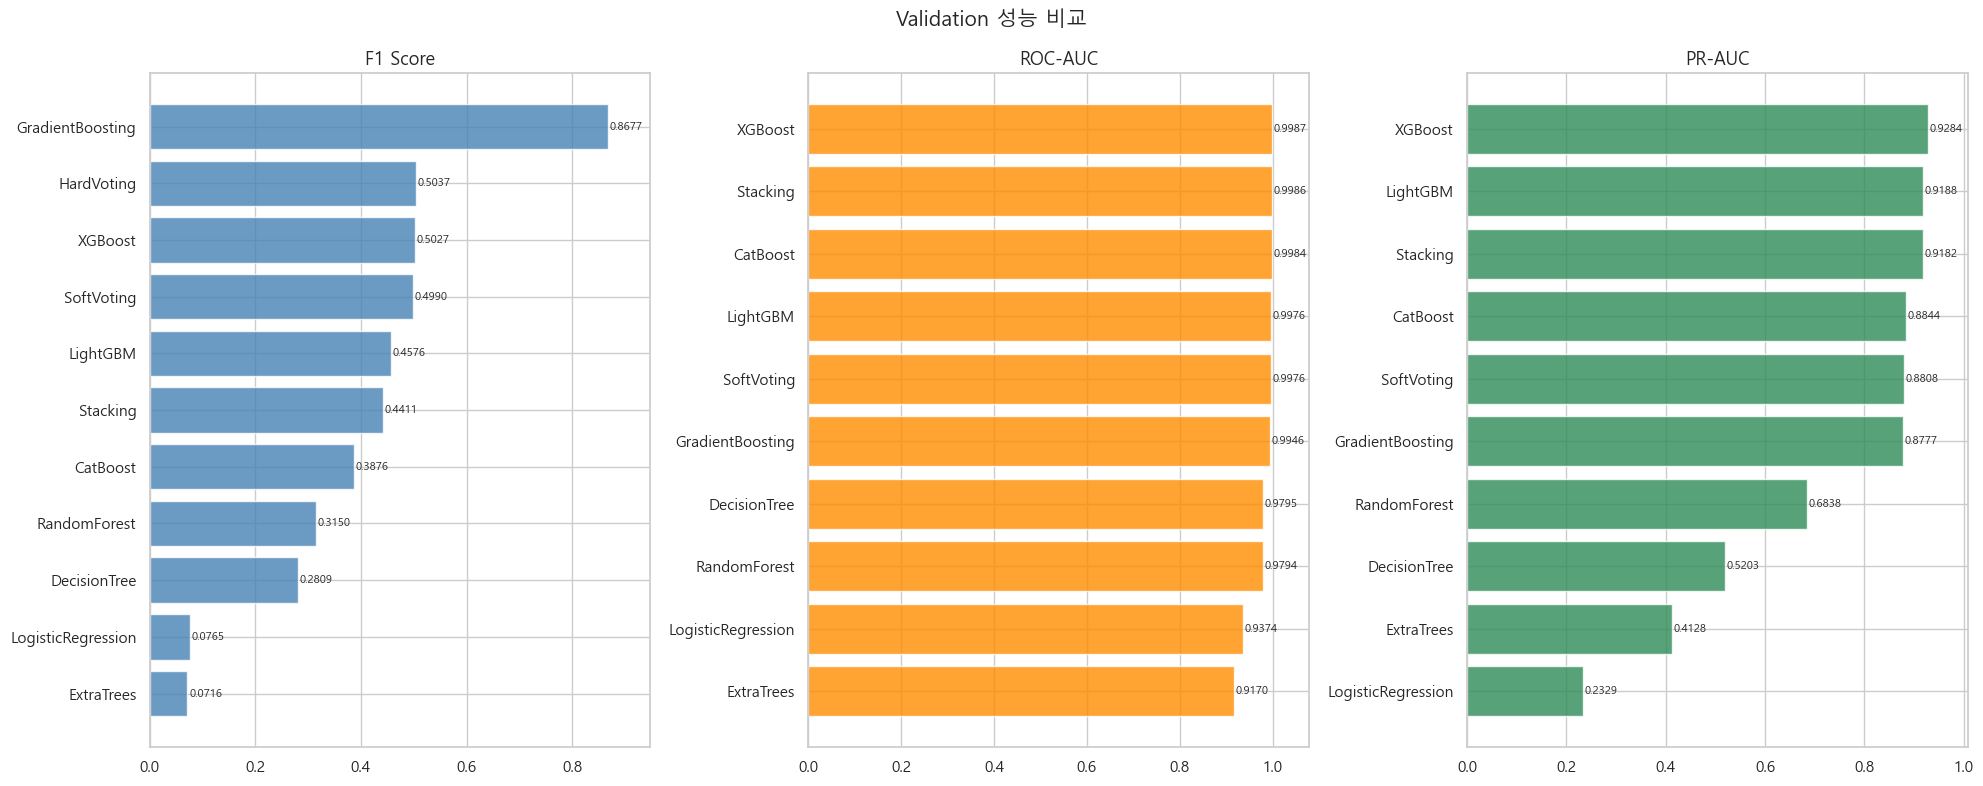

In [9]:
# ── 모델 성능 비교 바 차트 ────────────────────────────────────
# 중복행 제거
plot_df = results_df.drop_duplicates(subset="model").reset_index(drop=True)

fig, axes = plt.subplots(1, 3, figsize=(20, 8))

metrics = ["f1", "roc_auc", "pr_auc"]
titles  = ["F1 Score", "ROC-AUC", "PR-AUC"]
colors  = ["steelblue", "darkorange", "seagreen"]

for ax, metric, title, color in zip(axes, metrics, titles, colors):
    sorted_df = plot_df.sort_values(metric, ascending=True)
    ax.barh(sorted_df["model"], sorted_df[metric], color=color, alpha=0.8)
    ax.set_title(title, fontsize=13)

    # ↓ 수정: 고정값 1.12 → 동적 계산으로 변경
    max_val = sorted_df[metric].max()
    ax.set_xlim(0, max_val + 0.08)

    for i, val in enumerate(sorted_df[metric]):
        ax.text(val + 0.003, i, f"{val:.4f}", va="center", fontsize=8)

plt.suptitle("Validation 성능 비교", fontsize=15)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "model_comparison.png", bbox_inches="tight", dpi=150)
plt.show()

최고 모델: XGBoost
  f1      = 0.5027
  roc_auc = 0.9987
  pr_auc  = 0.9284

classification report
              precision    recall  f1-score   support

           0       1.00      0.99      0.99    257834
           1       0.34      0.97      0.50      1501

    accuracy                           0.99    259335
   macro avg       0.67      0.98      0.75    259335
weighted avg       1.00      0.99      0.99    259335



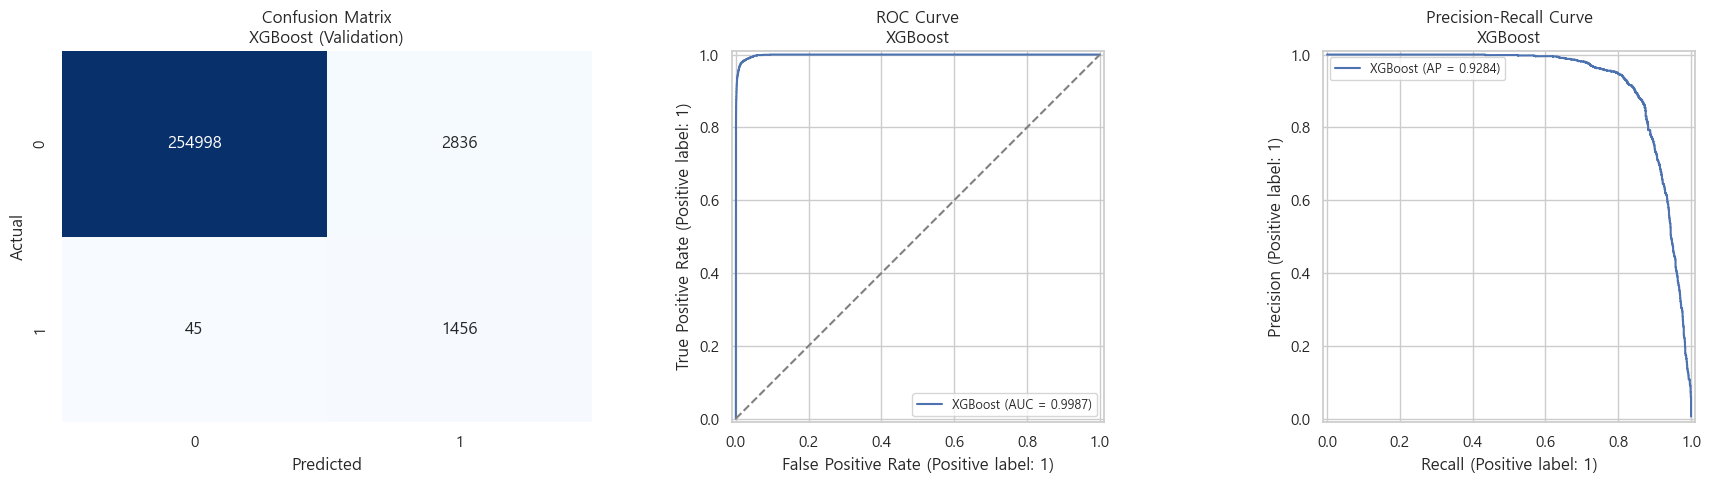

In [10]:
# ── 최고 모델 선택 (pr_auc 기준) 및 상세 시각화 ──────────────
best_model_name = results_df.iloc[0]["model"]
best_pipeline   = trained_pipelines[best_model_name]

print(f"최고 모델: {best_model_name}")
print(f"  f1      = {results_df.iloc[0]['f1']:.4f}")
print(f"  roc_auc = {results_df.iloc[0]['roc_auc']:.4f}")
print(f"  pr_auc  = {results_df.iloc[0]['pr_auc']:.4f}")

valid_pred  = best_pipeline.predict(X_valid)
valid_proba = best_pipeline.predict_proba(X_valid)[:, 1]

print("\nclassification report")
print(classification_report(y_valid, valid_pred, zero_division=0))

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Confusion Matrix
cm = confusion_matrix(y_valid, valid_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False, ax=axes[0])
axes[0].set_title(f"Confusion Matrix\n{best_model_name} (Validation)")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Actual")

# ROC Curve — AUC 소수점 4자리
roc_display = RocCurveDisplay.from_predictions(y_valid, valid_proba, ax=axes[1])
auc_val = roc_auc_score(y_valid, valid_proba)
roc_display.line_.set_label(f"{best_model_name} (AUC = {auc_val:.4f})")
axes[1].set_title(f"ROC Curve\n{best_model_name}")
axes[1].plot([0, 1], [0, 1], "--", color="gray")
axes[1].legend(fontsize=9)

# PR Curve — AP 소수점 4자리
pr_display = PrecisionRecallDisplay.from_predictions(y_valid, valid_proba, ax=axes[2])
ap_val = average_precision_score(y_valid, valid_proba)
pr_display.line_.set_label(f"{best_model_name} (AP = {ap_val:.4f})")
axes[2].set_title(f"Precision-Recall Curve\n{best_model_name}")
axes[2].legend(fontsize=9)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / f"best_model_{best_model_name}_curves.png", bbox_inches="tight", dpi=150)
plt.show()

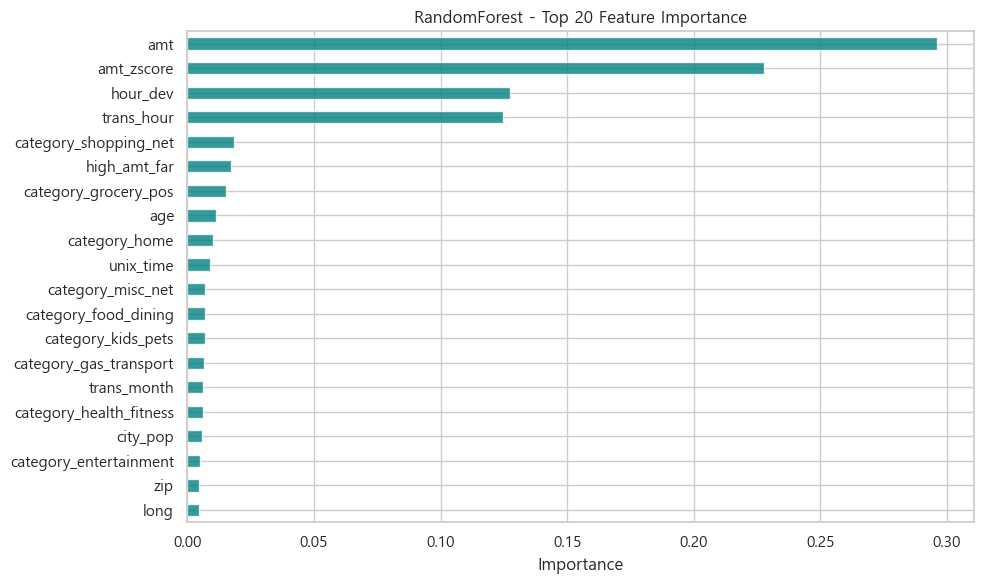

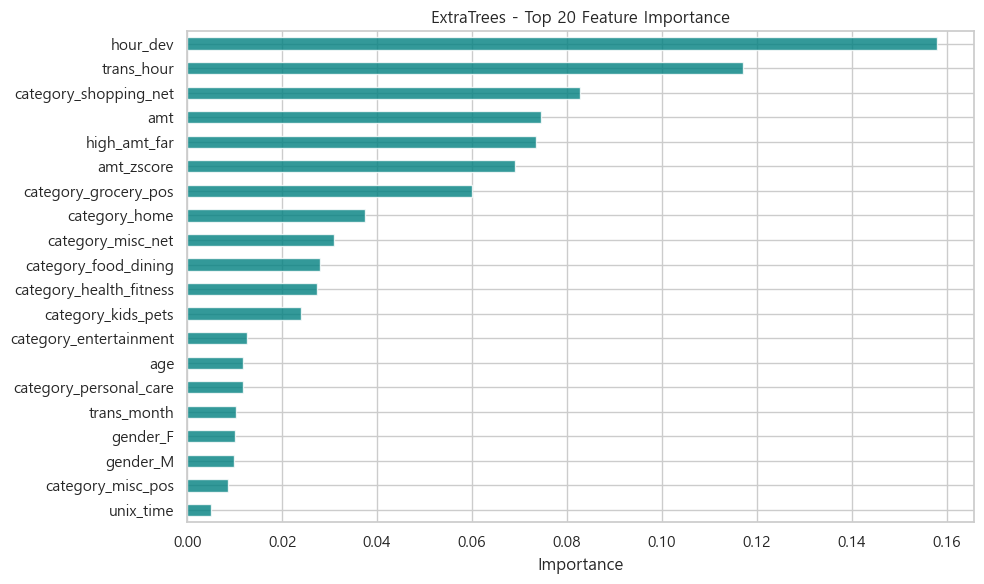

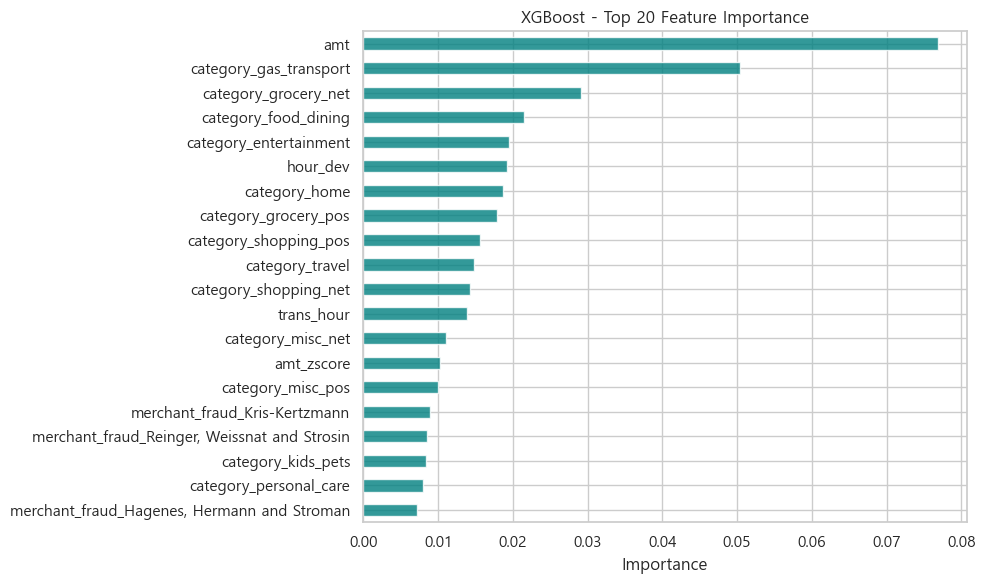

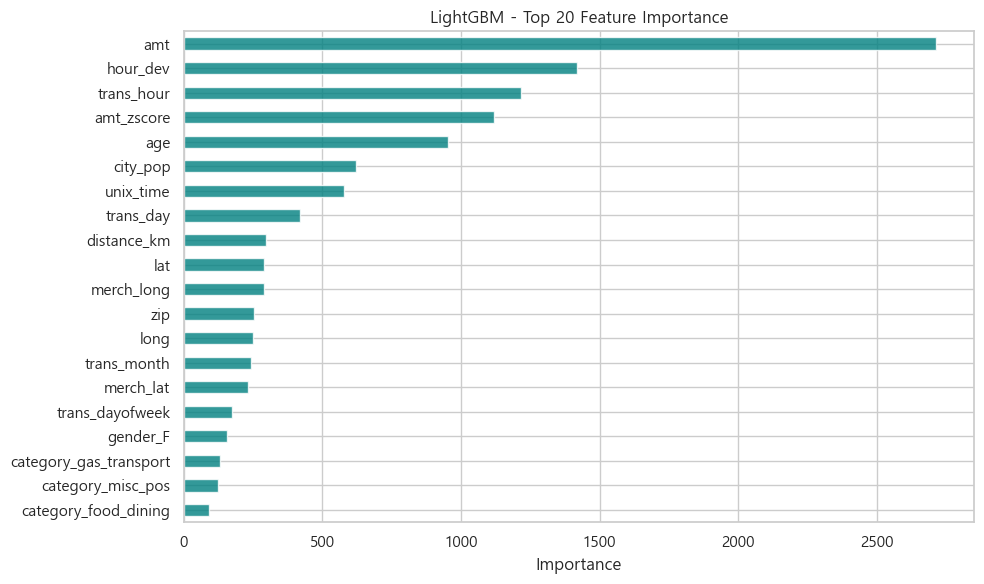

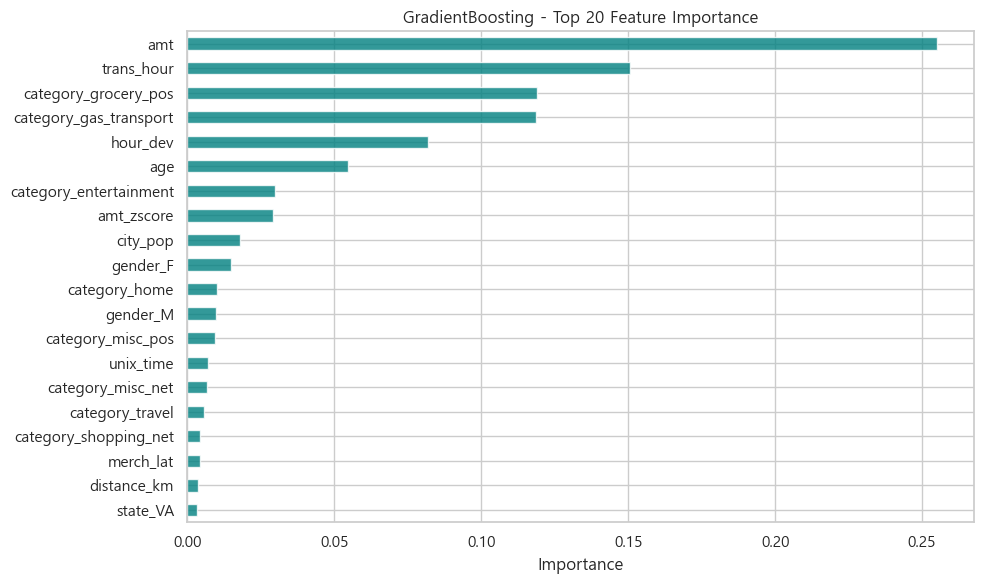

In [11]:
# ── Feature Importance (트리 계열 모델) ──────────────────────
def plot_feature_importance(pipeline, model_name, top_n=20):
    """파이프라인에서 feature importance 추출 후 시각화"""
    model = pipeline.named_steps["model"]
    prep  = pipeline.named_steps["preprocessor"]

    if not hasattr(model, "feature_importances_"):
        print(f"{model_name}: feature_importances_ 없음 (건너뜀)")
        return

    try:
        feat_names = prep.get_feature_names_out()
    except Exception:
        feat_names = [f"f{i}" for i in range(len(model.feature_importances_))]

    fi = pd.Series(model.feature_importances_, index=feat_names).sort_values(ascending=False)

    fig, ax = plt.subplots(figsize=(10, 6))
    fi.head(top_n).sort_values().plot.barh(ax=ax, color="teal", alpha=0.8)
    ax.set_title(f"{model_name} - Top {top_n} Feature Importance")
    ax.set_xlabel("Importance")
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / f"feature_importance_{model_name}.png", bbox_inches="tight", dpi=150)
    plt.show()

# 트리 계열 모델 importance 출력
for name in ["RandomForest", "ExtraTrees", "XGBoost", "LightGBM", "GradientBoosting"]:
    if name in trained_pipelines:
        plot_feature_importance(trained_pipelines[name], name)


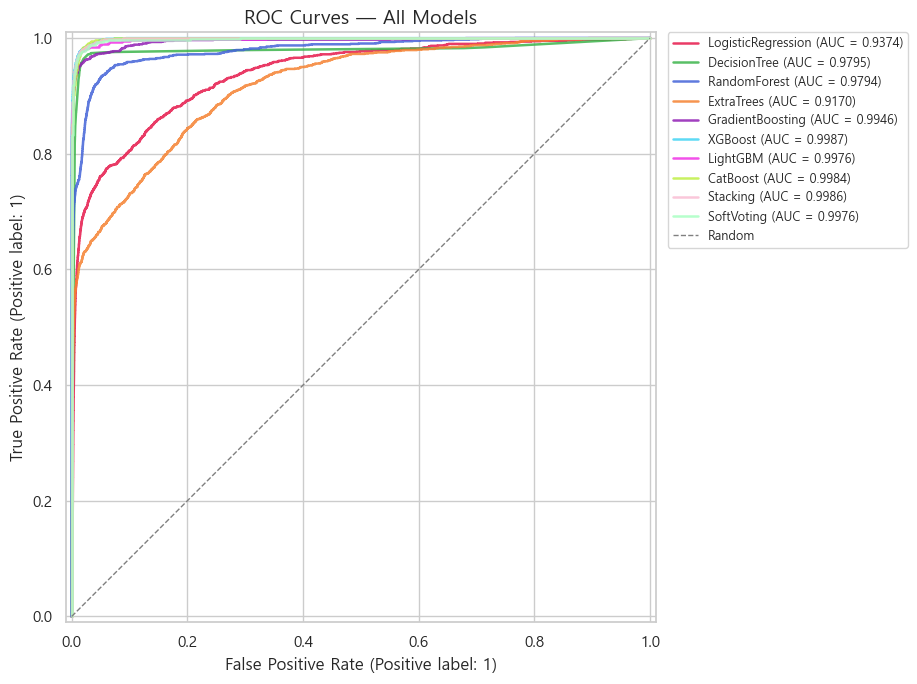

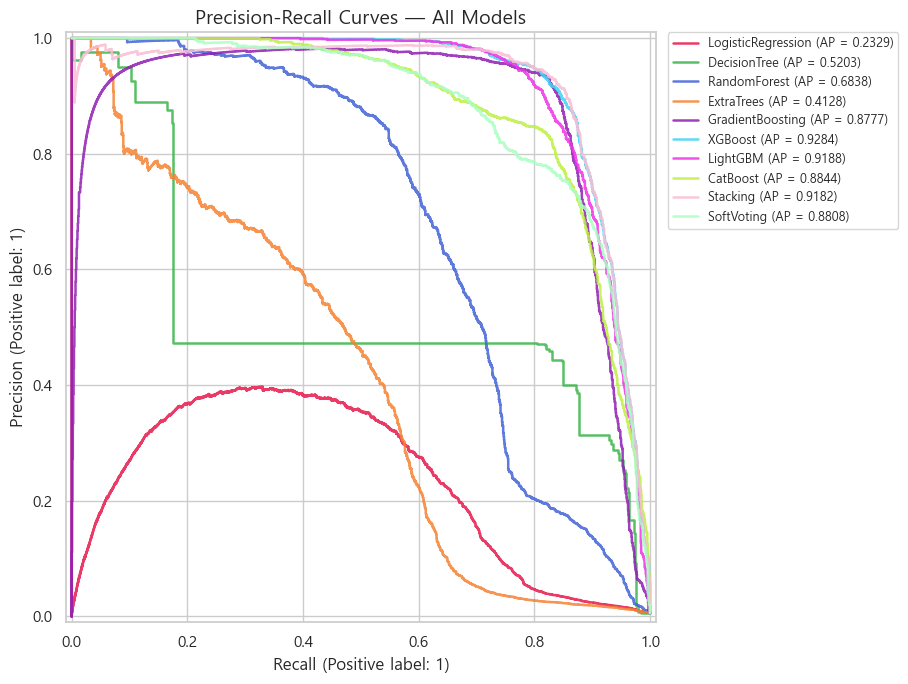

In [12]:
# ── 전체 모델 ROC / PR 곡선 (Pipeline 통일 버전) ────────────
PALETTE = [
    "#e6194b", "#3cb44b", "#4363d8", "#f58231", "#911eb4",
    "#42d4f4", "#f032e6", "#bfef45", "#fabed4", "#aaffc3",
]

# ── ROC 곡선 ─────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 7))
for (name, pipeline), color in zip(trained_pipelines.items(), PALETTE):
    if not hasattr(pipeline, "predict_proba"):
        continue
    proba   = pipeline.predict_proba(X_valid)[:, 1]
    auc_val = roc_auc_score(y_valid, proba)
    roc_disp = RocCurveDisplay.from_predictions(
        y_valid, proba, ax=ax, color=color, alpha=0.85, lw=1.8,
    )
    roc_disp.line_.set_label(f"{name} (AUC = {auc_val:.4f})")
ax.plot([0, 1], [0, 1], "--", color="gray", lw=1, label="Random")
ax.set_title("ROC Curves — All Models", fontsize=14)
ax.legend(loc="upper left", bbox_to_anchor=(1.02, 1), borderaxespad=0, fontsize=9)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "roc_curves.png", bbox_inches="tight", dpi=150)
plt.show()

# ── PR 곡선 ──────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 7))
for (name, pipeline), color in zip(trained_pipelines.items(), PALETTE):
    if not hasattr(pipeline, "predict_proba"):
        continue
    proba  = pipeline.predict_proba(X_valid)[:, 1]
    ap_val = average_precision_score(y_valid, proba)
    pr_disp = PrecisionRecallDisplay.from_predictions(
        y_valid, proba, ax=ax, color=color, alpha=0.85, lw=1.8,
    )
    pr_disp.line_.set_label(f"{name} (AP = {ap_val:.4f})")
ax.set_title("Precision-Recall Curves — All Models", fontsize=14)
ax.legend(loc="upper left", bbox_to_anchor=(1.02, 1), borderaxespad=0, fontsize=9)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "pr_curves.png", bbox_inches="tight", dpi=150)
plt.show()


In [13]:
# ── 최고 모델 test 성능 평가 ──────────────────────────────────
if y_test is not None:
    test_pred  = best_pipeline.predict(X_test)
    test_proba = best_pipeline.predict_proba(X_test)[:, 1]

    print(f"[{best_model_name}] 테스트 성능")
    print(f"  accuracy  : {accuracy_score(y_test, test_pred):.4f}")
    print(f"  precision : {precision_score(y_test, test_pred, zero_division=0):.4f}")
    print(f"  recall    : {recall_score(y_test, test_pred, zero_division=0):.4f}")
    print(f"  f1        : {f1_score(y_test, test_pred, zero_division=0):.4f}")
    print(f"  roc_auc   : {roc_auc_score(y_test, test_proba):.4f}")
    print(f"  pr_auc    : {average_precision_score(y_test, test_proba):.4f}")
    print("classification report")
    print(classification_report(y_test, test_pred, zero_division=0))
else:
    print("y_test 없음 — 예측 결과를 CSV로 저장합니다.")
    submission = pd.DataFrame({"is_fraud": best_pipeline.predict(X_test)})
    submission.to_csv(OUTPUT_DIR / f"submission_{best_model_name}.csv", index=False)
    print(f"저장 완료 → output/submission_{best_model_name}.csv")


[XGBoost] 테스트 성능
  accuracy  : 0.9910
  precision : 0.2917
  recall    : 0.9389
  f1        : 0.4451
  roc_auc   : 0.9970
  pr_auc    : 0.8612
classification report
              precision    recall  f1-score   support

           0       1.00      0.99      1.00    553574
           1       0.29      0.94      0.45      2145

    accuracy                           0.99    555719
   macro avg       0.65      0.97      0.72    555719
weighted avg       1.00      0.99      0.99    555719



In [14]:
# ── 전체 모델 pkl 저장 ────────────────────────────────────────
for name, pipeline in trained_pipelines.items():
    path = MODEL_DIR / f"{name.lower()}_model.pkl"
    joblib.dump(pipeline, path)
    print(f"저장 완료 → {path.resolve()}")

저장 완료 → D:\Lecture\03_Bootcamp\Teamproject\model\logisticregression_model.pkl
저장 완료 → D:\Lecture\03_Bootcamp\Teamproject\model\decisiontree_model.pkl
저장 완료 → D:\Lecture\03_Bootcamp\Teamproject\model\randomforest_model.pkl
저장 완료 → D:\Lecture\03_Bootcamp\Teamproject\model\extratrees_model.pkl
저장 완료 → D:\Lecture\03_Bootcamp\Teamproject\model\gradientboosting_model.pkl
저장 완료 → D:\Lecture\03_Bootcamp\Teamproject\model\xgboost_model.pkl
저장 완료 → D:\Lecture\03_Bootcamp\Teamproject\model\lightgbm_model.pkl
저장 완료 → D:\Lecture\03_Bootcamp\Teamproject\model\catboost_model.pkl
저장 완료 → D:\Lecture\03_Bootcamp\Teamproject\model\stacking_model.pkl
저장 완료 → D:\Lecture\03_Bootcamp\Teamproject\model\softvoting_model.pkl
저장 완료 → D:\Lecture\03_Bootcamp\Teamproject\model\hardvoting_model.pkl


In [15]:
# ── XGBoost 하이퍼파라미터 튜닝 (Optuna) ─────────────────────
# pip install optuna 필요
N_TRIALS = 100  # 시간 여유 있으면 100으로 늘려도 됨

def objective(trial):
    params = {
        "n_estimators":      trial.suggest_int("n_estimators",    100, 500),
        "max_depth":         trial.suggest_int("max_depth",        3,  10),
        "learning_rate":     trial.suggest_float("learning_rate",  0.01, 0.3, log=True),
        "subsample":         trial.suggest_float("subsample",      0.6, 1.0),
        "colsample_bytree":  trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "min_child_weight":  trial.suggest_int("min_child_weight", 1,  10),
        "gamma":             trial.suggest_float("gamma",          0.0, 1.0),
        "reg_alpha":         trial.suggest_float("reg_alpha",      1e-4, 10.0, log=True),
        "reg_lambda":        trial.suggest_float("reg_lambda",     1e-4, 10.0, log=True),
        # 불균형 보정 고정
        "scale_pos_weight":  scale_pos,
        "eval_metric":       "aucpr",
        "use_label_encoder": False,
        "n_jobs":            -1,
        "random_state":      RANDOM_STATE,
    }

    pipeline = Pipeline(steps=[
        ("preprocessor", clone(preprocessor)),
        ("model", XGBClassifier(**params)),
    ])
    pipeline.fit(X_train, y_train)

    proba = pipeline.predict_proba(X_valid)[:, 1]
    return average_precision_score(y_valid, proba)  # PR-AUC 최대화

# ── 탐색 실행 ─────────────────────────────────────────────────
print(f"Optuna 탐색 시작 ({N_TRIALS} trials) ...")
t0 = time.time()

study = optuna.create_study(
    direction="maximize",
    sampler=TPESampler(seed=RANDOM_STATE),
)
study.optimize(objective, n_trials=N_TRIALS, show_progress_bar=True)

elapsed = time.time() - t0
print(f"\n탐색 완료 ({elapsed:.1f}s)")
print(f"best PR-AUC : {study.best_value:.4f}")
print(f"best params : {study.best_params}")

Optuna 탐색 시작 (100 trials) ...


Best trial: 93. Best value: 0.971654: 100%|██████████| 100/100 [1:17:46<00:00, 46.67s/it]


탐색 완료 (4667.0s)
best PR-AUC : 0.9717
best params : {'n_estimators': 464, 'max_depth': 9, 'learning_rate': 0.21102999202807346, 'subsample': 0.8121494339648603, 'colsample_bytree': 0.8097982397670291, 'min_child_weight': 3, 'gamma': 0.7260562307083421, 'reg_alpha': 0.3234034313904896, 'reg_lambda': 5.9642387649381545}


In [16]:
# ── best params로 최종 모델 학습 ─────────────────────────────
best_params = {
    **study.best_params,
    "scale_pos_weight":  scale_pos,
    "eval_metric":       "aucpr",
    "use_label_encoder": False,
    "n_jobs":            -1,
    "random_state":      RANDOM_STATE,
}

tuned_pipeline = Pipeline(steps=[
    ("preprocessor", clone(preprocessor)),
    ("model", XGBClassifier(**best_params)),
])
tuned_pipeline.fit(X_train, y_train)

tuned_proba = tuned_pipeline.predict_proba(X_valid)[:, 1]
tuned_pr_auc = average_precision_score(y_valid, tuned_proba)
tuned_roc_auc = roc_auc_score(y_valid, tuned_proba)

print("── 튜닝 전후 비교 ───────────────────────")
print(f"{'':20} {'before':>10} {'after':>10}")
print("-" * 42)
print(f"{'PR-AUC':20} {results_df[results_df['model']=='XGBoost']['pr_auc'].values[0]:>10.4f} {tuned_pr_auc:>10.4f}")
print(f"{'ROC-AUC':20} {results_df[results_df['model']=='XGBoost']['roc_auc'].values[0]:>10.4f} {tuned_roc_auc:>10.4f}")

── 튜닝 전후 비교 ───────────────────────
                         before      after
------------------------------------------
PR-AUC                   0.9284     0.9717
ROC-AUC                  0.9987     0.9994


최적 임계값 : 0.58
최적 F2     : 0.9326


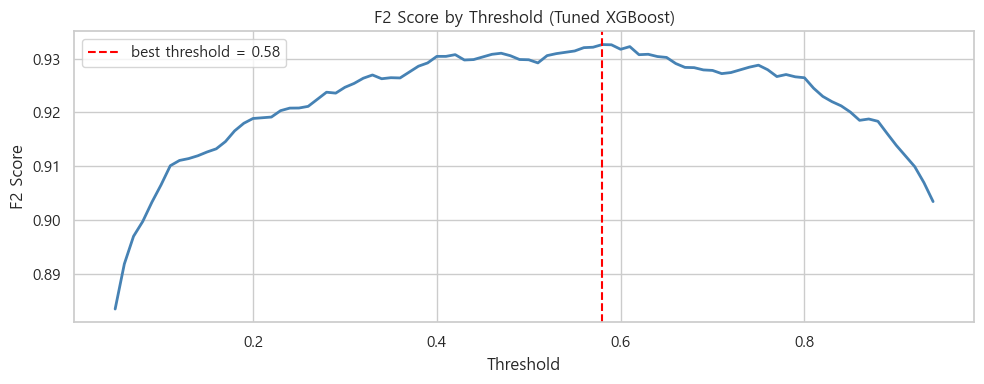

In [17]:
# ── 임계값 탐색 (F2 최대화) ───────────────────────────────────
from sklearn.metrics import fbeta_score
import numpy as np

thresholds = np.arange(0.05, 0.95, 0.01)
f2_scores  = [fbeta_score(y_valid, (tuned_proba >= t).astype(int),
                          beta=2, zero_division=0) for t in thresholds]

best_threshold = thresholds[np.argmax(f2_scores)]
best_f2        = max(f2_scores)

print(f"최적 임계값 : {best_threshold:.2f}")
print(f"최적 F2     : {best_f2:.4f}")

# 임계값별 F2 시각화
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(thresholds, f2_scores, color="steelblue", lw=2)
ax.axvline(best_threshold, color="red", linestyle="--", label=f"best threshold = {best_threshold:.2f}")
ax.set_xlabel("Threshold")
ax.set_ylabel("F2 Score")
ax.set_title("F2 Score by Threshold (Tuned XGBoost)")
ax.legend()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "threshold_f2.png", bbox_inches="tight", dpi=150)
plt.show()

In [18]:
# ── 최종 평가 ─────────────────────────────────────────────────
final_pred = (tuned_proba >= best_threshold).astype(int)

print(f"최종 성능 (threshold = {best_threshold:.2f})")
print(f"  F2        : {fbeta_score(y_valid, final_pred, beta=2, zero_division=0):.4f}")
print(f"  F1        : {f1_score(y_valid, final_pred, zero_division=0):.4f}")
print(f"  Recall    : {recall_score(y_valid, final_pred, zero_division=0):.4f}")
print(f"  Precision : {precision_score(y_valid, final_pred, zero_division=0):.4f}")
print(f"  PR-AUC    : {tuned_pr_auc:.4f}")
print(f"  ROC-AUC   : {tuned_roc_auc:.4f}")
print()
print(classification_report(y_valid, final_pred, zero_division=0))

# 최종 모델 저장
joblib.dump(tuned_pipeline, MODEL_DIR / "xgboost_tuned.pkl")
print("저장 완료 → model/xgboost_tuned.pkl")

최종 성능 (threshold = 0.58)
  F2        : 0.9326
  F1        : 0.9265
  Recall    : 0.9367
  Precision : 0.9166
  PR-AUC    : 0.9717
  ROC-AUC   : 0.9994

              precision    recall  f1-score   support

           0       1.00      1.00      1.00    257834
           1       0.92      0.94      0.93      1501

    accuracy                           1.00    259335
   macro avg       0.96      0.97      0.96    259335
weighted avg       1.00      1.00      1.00    259335

저장 완료 → model/xgboost_tuned.pkl
